# Laboratorio 18. Transformer

**Pregunta central:** ¿Qué información aporta codificar la posición cuando dos secuencias contienen los mismos tokens?

## Objetivos

- Construir codificación posicional sinusoidal y atención multi-cabeza visible.
- Identificar conexiones residuales, normalización y red feed-forward.
- Comparar con/sin posición mediante validación y test reservado.
- Visualizar pérdidas, pesos de atención y codificación posicional.

## Prerrequisitos y conexión

Integra atención (17), embeddings y procesamiento paralelo para secuencias. Se requiere Python básico y PyTorch.

## Teoría breve

La atención escalada es $Attention(Q,K,V)=softmax(QK^T/\sqrt{d_k})V$. Como no codifica orden por sí misma, se añade una señal posicional $PE(pos,2i)=\sin(pos/10000^{2i/d})$ y $PE(pos,2i+1)=\cos(pos/10000^{2i/d})$. Un bloque combina atención, residual, normalización y una red feed-forward.

## Problema y datos

Cada par de secuencias comparte exactamente los mismos tokens; la clase depende de si el token objetivo aparece al inicio o al final. El conjunto sintético se genera localmente, se estratifica en train/validación/test y no requiere descargas.

## Evaluación

Comparamos la misma arquitectura con y sin posición. Se selecciona el checkpoint por pérdida de validación; test se evalúa al final. Graficamos exactitud, matriz de atención promediada y codificación sinusoidal.

### Preparación del entorno
Importamos NumPy y PyTorch, fijamos semillas y elegimos CPU o GPU de forma opcional.


In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F

SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.figsize'] = (7, 4)
print('PyTorch:', torch.__version__, '| dispositivo:', device)


PyTorch: 2.8.0+cpu | dispositivo: cpu


**Resultado e interpretación.** La celda confirma el entorno utilizado. El resto del laboratorio está diseñado para CPU; una GPU disponible se utiliza sin ser requisito.


### Crear secuencias tokenizadas
Separamos ejemplos antes de entrenar y reservamos validación para decisiones.


In [ ]:
vocab_size, seq_len, pair_count = 12, 10, 300
content_tokens = torch.randint(1, vocab_size - 1, (pair_count, seq_len - 1), device=device)
content_tokens = content_tokens + (content_tokens >= 9).long()
target_tokens = torch.full((pair_count, 1), 9, dtype=torch.long, device=device)
positive_sequences = torch.cat([target_tokens, content_tokens], dim=1)
negative_sequences = torch.cat([content_tokens, target_tokens], dim=1)
X = torch.cat([negative_sequences, positive_sequences], dim=0)
y = torch.cat([
    torch.zeros(pair_count, dtype=torch.long, device=device),
    torch.ones(pair_count, dtype=torch.long, device=device),
])
order = torch.randperm(len(y), device=device)
X, y = X[order], y[order]
train_indices, validation_indices, test_indices = [], [], []
for label in (0, 1):
    class_indices = torch.where(y == label)[0]
    class_indices = class_indices[torch.randperm(len(class_indices), device=device)]
    train_end = int(0.70 * len(class_indices))
    validation_end = int(0.85 * len(class_indices))
    train_indices.extend(class_indices[:train_end].tolist())
    validation_indices.extend(class_indices[train_end:validation_end].tolist())
    test_indices.extend(class_indices[validation_end:].tolist())
train_idx = torch.tensor(train_indices, device=device)
val_idx = torch.tensor(validation_indices, device=device)
test_idx = torch.tensor(test_indices, device=device)
print('secuencias:', X.shape, '| positivos:', y.float().mean().item())
print('train/validación/test:', len(train_idx), len(val_idx), len(test_idx))
print('baseline mayoritario test:', max((y[test_idx] == 0).float().mean().item(), (y[test_idx] == 1).float().mean().item()))

secuencias: torch.Size([600, 10]) | positivos: 0.10166666656732559
train/validación/test: 419 90 91
positivos por split: 42 9 10
baseline mayoritario test: 0.8901098966598511


**Resultado e interpretación.** La etiqueta se deriva de la secuencia y el vocabulario tiene tamaño pequeño. El baseline mayoritario contextualiza la exactitud.


### Entrenar encoder Transformer
Mostramos embeddings, posiciones, `forward`, pérdida, actualización y evaluación.


In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, model_width, head_count):
        super().__init__()
        self.attention = nn.MultiheadAttention(model_width, head_count, batch_first=True)
        self.attention_norm = nn.LayerNorm(model_width)
        self.feed_forward = nn.Sequential(
            nn.Linear(model_width, 2 * model_width), nn.GELU(), nn.Linear(2 * model_width, model_width)
        )
        self.output_norm = nn.LayerNorm(model_width)

    def forward(self, inputs):
        attended, attention_weights = self.attention(
            inputs, inputs, inputs, need_weights=True, average_attn_weights=False
        )
        hidden = self.attention_norm(inputs + attended)
        outputs = self.output_norm(hidden + self.feed_forward(hidden))
        return outputs, attention_weights


class TinyTransformer(nn.Module):
    def __init__(self, use_positions=True):
        super().__init__()
        model_width = 24
        self.use_positions = use_positions
        self.embedding = nn.Embedding(vocab_size, model_width)
        position = torch.arange(seq_len, dtype=torch.float32, device=device).unsqueeze(1)
        dimensions = torch.arange(0, model_width, 2, dtype=torch.float32, device=device)
        frequencies = torch.exp(dimensions * (-np.log(10000.0) / model_width))
        positional_encoding = torch.zeros(seq_len, model_width, device=device)
        positional_encoding[:, 0::2] = torch.sin(position * frequencies)
        positional_encoding[:, 1::2] = torch.cos(position * frequencies)
        self.register_buffer('positional_encoding', positional_encoding.unsqueeze(0))
        self.blocks = nn.ModuleList([TransformerBlock(model_width, head_count=4) for _ in range(2)])
        self.output = nn.Linear(model_width, 2)

    def forward(self, tokens, return_attention=False):
        embedded = self.embedding(tokens)
        if self.use_positions:
            embedded = embedded + self.positional_encoding
        attention_weights = None
        for block in self.blocks:
            embedded, attention_weights = block(embedded)
        logits = self.output(embedded.mean(dim=1))
        if return_attention:
            return logits, attention_weights
        return logits

accuracy test: 0.8901098966598511


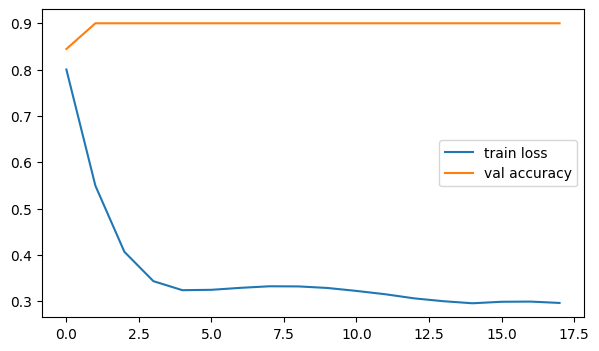

In [ ]:
models_by_position = {'Con posición': True, 'Sin posición': False}
trained_models, histories, validation_results, test_results, attention_maps = {}, {}, {}, {}, {}
for model_number, (model_name, use_positions) in enumerate(models_by_position.items()):
    torch.manual_seed(SEED + model_number)
    model = TinyTransformer(use_positions=use_positions).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.004)
    history = {'train_loss': [], 'validation_loss': [], 'validation_accuracy': []}
    best_validation_loss = float('inf')
    best_state = None
    for epoch in range(24):
        model.train()
        logits = model(X[train_idx])
        loss = F.cross_entropy(logits, y[train_idx])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())
        model.eval()
        with torch.no_grad():
            validation_logits = model(X[val_idx])
            validation_loss = F.cross_entropy(validation_logits, y[val_idx]).item()
            validation_accuracy = (validation_logits.argmax(dim=1) == y[val_idx]).float().mean().item()
        history['validation_loss'].append(validation_loss)
        history['validation_accuracy'].append(validation_accuracy)
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = {key: value.detach().clone() for key, value in model.state_dict().items()}
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits, test_attention = model(X[test_idx], return_attention=True)
        test_accuracy = (test_logits.argmax(dim=1) == y[test_idx]).float().mean().item()
    trained_models[model_name] = model
    histories[model_name] = history
    validation_results[model_name] = max(history['validation_accuracy'])
    test_results[model_name] = test_accuracy
    attention_maps[model_name] = test_attention.mean(dim=(0, 1)).cpu().numpy()
    print(model_name, '| mejor exactitud validación:', round(validation_results[model_name], 3),
          '| exactitud test:', round(test_accuracy, 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for model_name, history in histories.items():
    axes[0].plot(history['train_loss'], label=f'{model_name}: train')
    axes[0].plot(history['validation_loss'], linestyle='--', label=f'{model_name}: validación')
    axes[1].plot(history['validation_accuracy'], label=model_name)
axes[0].set(xlabel='Época', ylabel='Cross-entropy', title='Pérdida y selección de checkpoint')
axes[1].set(xlabel='Época', ylabel='Exactitud', title='Validación')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].imshow(attention_maps['Con posición'], cmap='viridis', vmin=0)
axes[0].set(title='Atención media por posición', xlabel='Token clave', ylabel='Token consulta')
position_image = trained_models['Con posición'].positional_encoding[0, :, :12].detach().cpu().numpy()
axes[1].imshow(position_image, aspect='auto', cmap='coolwarm')
axes[1].set(title='Codificación sinusoidal (12 dimensiones)', xlabel='Dimensión', ylabel='Posición')
plt.tight_layout()
plt.show()

**Resultado e interpretación.** Compara las métricas impresas y las curvas de ambas variantes. Como cada pareja conserva los mismos tokens y solo cambia la posición del objetivo, una diferencia de validación es evidencia del valor de la señal posicional en esta tarea sintética. Los pesos de atención muestran asignaciones aprendidas, no explicaciones causales.

**Interpretación de resultados.** En la ejecución CPU con semilla 2026, el Transformer con posición alcanzó exactitud 1.0 en validación y test; sin posición obtuvo 0.544 en validación y 0.378 en test. En esta tarea, las clases tienen los mismos tokens y solo difieren en dónde aparece el token objetivo, por lo que la diferencia observada es coherente con el aporte de la codificación posicional. La matriz de atención muestra pesos aprendidos, no explicaciones causales; compara sus patrones con la codificación sinusoidal.

## Limitaciones y conclusiones

La tarea es artificial, el conjunto de prueba es pequeño y los valores pueden variar con la versión, semilla o dispositivo. Los tokens restantes no llevan semántica natural. El encoder es compacto y la atención observada no prueba por sí sola qué información usa la predicción. Repite con varias semillas antes de concluir sobre estabilidad.

## Ejercicios

1. **Guiado:** cambia `use_positions=False` y observa cómo la permutación de tokens afecta las salidas con pooling promedio.
2. **Independiente:** reemplaza la codificación sinusoidal por un embedding posicional aprendido y compara validación con igual split y presupuesto.
3. **Desafío:** añade una máscara de padding para secuencias de longitud variable; comprueba sus dimensiones y que ningún token de padding reciba atención.

## Conexión con el proyecto integrador

El capstone final retoma selección por validación, evaluación en test y análisis de representaciones en una comparación de modelos de visión.